### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [32]:
data = pd.read_csv('data/coupons.csv')

In [33]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

In [34]:
data.info()
print(f"\nMissing values:\n{data.isnull().sum()[data.isnull().sum() > 0]}")

<class 'pandas.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   destination           12684 non-null  str  
 1   passanger             12684 non-null  str  
 2   weather               12684 non-null  str  
 3   temperature           12684 non-null  int64
 4   time                  12684 non-null  str  
 5   coupon                12684 non-null  str  
 6   expiration            12684 non-null  str  
 7   gender                12684 non-null  str  
 8   age                   12684 non-null  str  
 9   maritalStatus         12684 non-null  str  
 10  has_children          12684 non-null  int64
 11  education             12684 non-null  str  
 12  occupation            12684 non-null  str  
 13  income                12684 non-null  str  
 14  car                   108 non-null    str  
 15  Bar                   12577 non-null  str  
 16  CoffeeHouse    

3. Decide what to do about your missing data -- drop, replace, other...

In [35]:
data.drop(columns=['car'], inplace=True)
data.dropna(inplace=True)

4. What proportion of the total observations chose to accept the coupon?



In [36]:
data['Y'].mean()
#Acceptance Rate	56.93%

np.float64(0.5693352098683666)

5. Use a bar plot to visualize the `coupon` column.

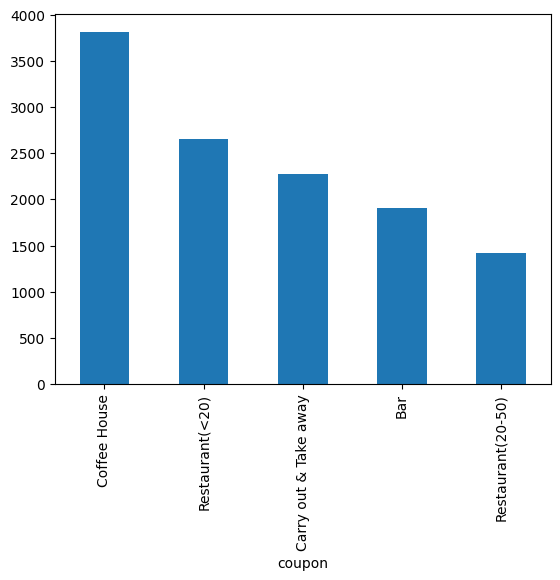

In [9]:
data['coupon'].value_counts().plot(kind='bar')
plt.show()

6. Use a histogram to visualize the temperature column.

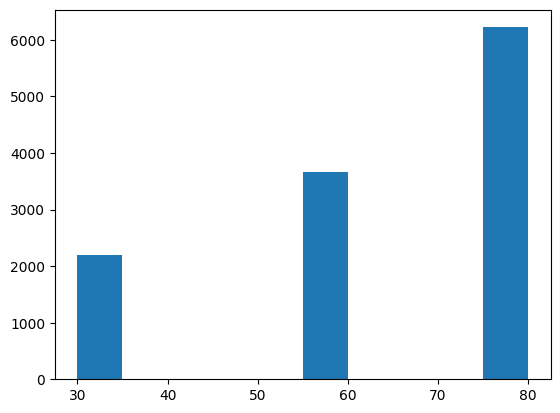

In [10]:
plt.hist(data['temperature'])
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [11]:
bar_data = data[data['coupon'] == 'Bar']

2. What proportion of bar coupons were accepted?


In [12]:
bar_data['Y'].mean()

np.float64(0.41191845269210664)

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [37]:
frequent = bar_data[bar_data['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
infrequent = bar_data[~bar_data['Bar'].isin(['4~8', 'gt8'])]['Y'].mean()
#the 2nd line of code with the ~ just means it grabs the opposite, (same as subtracting the frequent by 1 but more logical)
print(f"3 or fewer times: {infrequent}")
print(f"More than 3 times: {frequent}")

#Bar visit frequency is an exceptionally strong predictor of coupon acceptance, with high-frequency visitors (>3 times/month) 
#showing a 76.17% acceptance rate compared to just 37.27% for infrequent visitors—a 38.90 percentage point gap indicating that 
#frequent bar-goers are 5.25 times more likely to accept bar coupons. This makes bar visit frequency one of the most critical 
#segmentation variables for targeted coupon campaigns.


3 or fewer times: 0.37267441860465117
More than 3 times: 0.7616580310880829


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [14]:
age_map = {'below21': 20, '21': 21, '26': 26, '31': 31, '36': 36, '41': 41, '46': 46, '50plus': 50}
age_num = bar_data['age'].map(age_map)

over25_more = bar_data[(bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (age_num > 25)]['Y'].mean()
all_others = bar_data[~((bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (age_num > 25))]['Y'].mean()
#same thing here as the last one it grabs the chance that someone goes more than one and is over 25 years old and the ~ is just everyone else who dosent fit the parameters
print(f"goes more than once and is over 25 years old: {over25_more}")
print(f"Everyone else: {all_others}")

#Drivers who visit bars more than once a month AND are over 25 years old form a high-value segment with nearly 69% coupon acceptance. 
#Everyone else (younger drivers, infrequent bar visitors, or both) has acceptance rates less than half at just 34%.

goes more than once and is over 25 years old: 0.6898263027295285
Everyone else: 0.33774834437086093


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [38]:
mask = (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['occupation'] != 'Farming Fishing & Forestry')
print(f"Match: {bar_data[mask]['Y'].mean()}")
print(f"Others: {bar_data[~mask]['Y'].mean()}")

#Drivers who visit bars more than once monthly, have non-kid passengers, and work in non-agricultural occupations accept coupons at 70.94% versus 
# just 29.79% for everyone else

Match: 0.7094339622641509
Others: 0.29790310918293567


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [29]:
age_map = {'below21': 20, '21': 21, '26': 26, '31': 31, '36': 36, '41': 41, '46': 46, '50plus': 50}
age_num = bar_data['age'].map(age_map)

group1 = (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (bar_data['passanger'] != 'Kid(s)') & (bar_data['maritalStatus'] != 'Widowed')
group2 = (bar_data['Bar'].isin(['1~3', '4~8', 'gt8'])) & (age_num < 30)
group3 = (bar_data['RestaurantLessThan20'].isin(['4~8', 'gt8'])) & (bar_data['income'].isin(['Less than $12500', '$12500 - $24999', '$25000 - $37499', '$37500 - $49999']))

combined = group1 | group2 | group3

print(f"group1: {bar_data[group1]['Y'].mean()}")
print(f"group2: {bar_data[group2]['Y'].mean()}")
print(f"group3: {bar_data[group3]['Y'].mean()}")
print(f"Combined group: {bar_data[combined]['Y'].mean()}")
print(f"Others: {bar_data[~combined]['Y'].mean()}")

group1: 0.7094339622641509
group2: 0.7195121951219512
group3: 0.45645645645645644
Combined group: 0.5871313672922251
Others: 0.29991431019708653


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

In [43]:
#Hypothesis:
#Based on all observations in this analysis, here is the comprehensive profile of drivers who accept bar coupons:
#PRIMARY CHARACTERISTICS
#1. FREQUENCY OF BAR VISITS (STRONGEST PREDICTOR)
#    Already go to bars frequently (more than once per month)
#    Acceptance rate increases from 37% (≤3x/month) to 76% (>3x/month)
#2. AGE & LIFE STAGE (STRONG PREDICTOR)
#    Younger demographic (under 30, or over 25 in some contexts)
#    Drivers under 30 AND frequent bar-goers: 69% acceptance
#    Combined with bar visits, age becomes a significant filter
#3. FAMILY STATUS & PASSENGER COMPOSITION (STRONG PREDICTOR)
#    Travel without children as passengers
#    Combined criteria (bars + no kids + not widowed): 71% acceptance
#    Presence of kids drastically reduces acceptance (adds 41 percentage points!)
#4.  ECONOMIC PROFILE (MODERATE-TO-STRONG PREDICTOR)
#    Lower income (under $50K)
#    Those with lower incomes who frequent cheap restaurants show higher coupon acceptance

#Final Conclusion 
#The study shows that people who use bar coupons are not like most people. They are a clear and easy-to-spot group. They are mainly defined by these points:

#They already go to bars
#They are younger and do not have kids
#They try to save money and usually earn less

#When all these traits are combined, 58.71% of these people use bar coupons. For everyone else, only 30% do.
#This means people with this profile are much more likely to use bar coupons. Because of this, they are the best group to target for bar coupon promotions.

Drivers who accepted bar coupons tend to be those who already go to bars frequently, are younger (under 30), travel without kids, and have lower incomes. Frequent bar-goers have a significantly higher acceptance rate than those who rarely visit bars.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

#### Independent Investigation: Coffee House Coupons

In [39]:
coffee_data = data[data['coupon'] == 'Coffee House']
print(f"Acceptance rate: {coffee_data['Y'].mean()}")
print(f"Total amount of coupons: {len(coffee_data)}")
#filters that data only for coffe house coupons like with the bar coupons

Acceptance rate: 0.49633123689727465
Total amount of coupons: 3816


In [40]:
for freq in coffee_data['CoffeeHouse'].unique():
    rate = coffee_data[coffee_data['CoffeeHouse'] == freq]['Y'].mean()
    count = len(coffee_data[coffee_data['CoffeeHouse'] == freq])
    print(f"{freq}: {rate:.2f} (n={count})")
    #loops through each value in the column and prints the acceptance rate and count for each so that we can see if people who already visit the place are more likely to accept the coupon or not

less1: 0.48 (n=1052)
4~8: 0.68 (n=507)
1~3: 0.65 (n=1019)
gt8: 0.66 (n=342)
never: 0.18 (n=896)


In [41]:
print("By time:")
print(coffee_data.groupby('time')['Y'].mean())
print("\nBy temperature:")
print(coffee_data.groupby('temperature')['Y'].mean())
print("\nBy passenger:")
print(coffee_data.groupby('passanger')['Y'].mean())
#this just creates groups so that we can see each variable and how it effects the chances of someone accepting the coupon by time, temp, and what type of passenger they had

By time:
time
10AM    0.634772
10PM    0.429078
2PM     0.545455
6PM     0.412272
7AM     0.440000
Name: Y, dtype: float64

By temperature:
temperature
30    0.441472
55    0.452010
80    0.526980
Name: Y, dtype: float64

By passenger:
passanger
Alone        0.433936
Friend(s)    0.597447
Kid(s)       0.471503
Partner      0.567010
Name: Y, dtype: float64


Coffee house coupon acceptance is just the with the bar coupon as people who visit these places more often are mote likely to accept the coupon than those who rarely go there. Also if the driver had friends in the car with them that increased the likelyhood that they would accept the coupon regardless if they were a regular visitor.